In [122]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [123]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

In [124]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])

df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[(df['시작_대여소_ID'].isin(target_station)) | (df['종료_대여소_ID'].isin(target_station))].copy()

df

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,datetime
0,2024-01-01,0,출발시간,ST-454,ST-1331,1.0,6900,11170.0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00
1,2024-01-01,0,출발시간,ST-454,ST-349,1.0,1560,4473.0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00
2,2024-01-01,0,출발시간,ST-454,ST-1025,1.0,720,1960.0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00
3,2024-01-01,0,출발시간,ST-479,ST-454,2.0,1200,2953.0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00
4,2024-01-01,0,출발시간,ST-1035,ST-3058,1.0,840,1821.0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160160,2025-12-31,22,출발시간,ST-3169,ST-1035,1.0,720,1590.0,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00
160161,2025-12-31,22,출발시간,ST-1035,ST-1035,1.0,780,1930.0,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00
160162,2025-12-31,22,출발시간,ST-454,ST-1038,1.0,3060,1511.0,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00
160163,2025-12-31,23,출발시간,ST-454,ST-479,1.0,480,1390.0,-8.8,51,27.43588,0.0,0.0,2025-12-31 23:00:00


In [125]:
st1035 = df[(df['시작_대여소_ID'].isin(target_station)) | (df['종료_대여소_ID'].isin(target_station))].copy()
st1035['유출입'] = np.where(
    st1035['시작_대여소_ID'] == 'ST-1035',
    -st1035['전체_건수'],
    st1035['전체_건수']
)

st1035.drop(['시작_대여소_ID', '종료_대여소_ID','전체_건수','전체_이용_분','전체_이용_거리','집계_기준'],axis=1,inplace=True)
st1035

,기준_날짜,시간대,온도,습도,불쾌지수,강수량,적설량,datetime,유출입
0,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,1.0
1,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,1.0
2,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,1.0
3,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,2.0
4,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,-1.0
...,...,...,...,...,...,...,...,...,...
160160,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,1.0
160161,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,-1.0
160162,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,1.0
160163,2025-12-31,23,-8.8,51,27.43588,0.0,0.0,2025-12-31 23:00:00,1.0


In [126]:
# 시작 대여소 하나에 대한 시간대별 합산 예시
df_1035_station = st1035.groupby(['기준_날짜','시간대']).agg({
    '유출입': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '불쾌지수': 'mean'
}).reset_index()
df_1035_station


,기준_날짜,시간대,유출입,온도,습도,강수량,적설량,불쾌지수
0,2024-01-01,0,13.0,-2.7,92.0,0.0,0.0,28.49784
1,2024-01-01,1,6.0,-1.2,87.0,0.0,0.0,31.85344
2,2024-01-01,2,15.0,-1.2,88.0,0.0,0.0,31.69856
3,2024-01-01,3,13.0,-1.1,88.0,0.0,0.0,31.86668
4,2024-01-01,4,2.0,-1.0,87.0,0.0,0.0,32.18770
...,...,...,...,...,...,...,...,...
16261,2025-12-31,19,13.0,-7.2,43.0,0.0,0.0,31.25396
16262,2025-12-31,20,6.0,-7.9,45.0,0.0,0.0,29.94655
16263,2025-12-31,21,2.0,-8.0,50.0,0.0,0.0,28.71000
16264,2025-12-31,22,4.0,-8.5,51.0,0.0,0.0,27.83035


In [127]:
df_1035_station['year'] = df_1035_station['기준_날짜'].dt.year
df_1035_station['month'] = df_1035_station['기준_날짜'].dt.month
df_1035_station['day'] = df_1035_station['기준_날짜'].dt.day
# df_1035_station['hour'] = df_1035_station['기준_날짜'].dt.hour
df_1035_station['weekday'] = df_1035_station['기준_날짜'].dt.dayofweek
df_1035_station['day_type'] = np.where(df_1035_station['weekday'] < 5, 0, 1)

df_1035_station['hour_sin'] = np.sin(2 * np.pi * df_1035_station['시간대'] / 24)
df_1035_station['hour_cos'] = np.cos(2 * np.pi * df_1035_station['시간대'] / 24)
df_1035_station['month_sin'] = np.sin(2 * np.pi * df_1035_station['month'] / 12)
df_1035_station['month_cos'] = np.cos(2 * np.pi * df_1035_station['month'] / 12)

df_1035_station


,기준_날짜,시간대,유출입,온도,습도,강수량,적설량,불쾌지수,year,month,day,weekday,day_type,hour_sin,hour_cos,month_sin,month_cos
0,2024-01-01,0,13.0,-2.7,92.0,0.0,0.0,28.49784,2024,1,1,0,0,0.000000,1.000000,5.000000e-01,0.866025
1,2024-01-01,1,6.0,-1.2,87.0,0.0,0.0,31.85344,2024,1,1,0,0,0.258819,0.965926,5.000000e-01,0.866025
2,2024-01-01,2,15.0,-1.2,88.0,0.0,0.0,31.69856,2024,1,1,0,0,0.500000,0.866025,5.000000e-01,0.866025
3,2024-01-01,3,13.0,-1.1,88.0,0.0,0.0,31.86668,2024,1,1,0,0,0.707107,0.707107,5.000000e-01,0.866025
4,2024-01-01,4,2.0,-1.0,87.0,0.0,0.0,32.18770,2024,1,1,0,0,0.866025,0.500000,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16261,2025-12-31,19,13.0,-7.2,43.0,0.0,0.0,31.25396,2025,12,31,2,0,-0.965926,0.258819,-2.449294e-16,1.000000
16262,2025-12-31,20,6.0,-7.9,45.0,0.0,0.0,29.94655,2025,12,31,2,0,-0.866025,0.500000,-2.449294e-16,1.000000
16263,2025-12-31,21,2.0,-8.0,50.0,0.0,0.0,28.71000,2025,12,31,2,0,-0.707107,0.707107,-2.449294e-16,1.000000
16264,2025-12-31,22,4.0,-8.5,51.0,0.0,0.0,27.83035,2025,12,31,2,0,-0.500000,0.866025,-2.449294e-16,1.000000


In [128]:
# 대여소별, 날짜별 누적 유출입 (오늘 자정부터 지금까지 얼마나 빠져나갔나?)
df_1035_station['net_flow_daily'] = df_1035_station.groupby(['기준_날짜'])['유출입'].cumsum()
df_1035_station = df_1035_station.sort_values(['기준_날짜', '시간대'])
df_1035_station['lag_1h'] = df_1035_station['유출입'].shift(1)
df_1035_station['lag_2h'] = df_1035_station['유출입'].shift(2)
df_1035_station['lag_3h'] = df_1035_station['유출입'].shift(3)

df_1035_station['rolling_flow_3h'] = df_1035_station['유출입'].shift(1).rolling(3).mean()

# df_1035_station['net_flow_until_last_hour'] = df_1035_station.groupby(['기준_날짜'])['유출입'].apply(lambda x: x.shift(1).cumsum()).fillna(0)

# df_1035_station['lag_24h'] = df_1035_station['유출입'].shift(24)
df_1035_station = df_1035_station.dropna()


# features.extend(['lag_1h', 'lag_24h'])
df_1035_station

,기준_날짜,시간대,유출입,온도,습도,강수량,적설량,불쾌지수,year,month,...,day_type,hour_sin,hour_cos,month_sin,month_cos,net_flow_daily,lag_1h,lag_2h,lag_3h,rolling_flow_3h
3,2024-01-01,3,13.0,-1.1,88.0,0.0,0.0,31.86668,2024,1,...,0,0.707107,7.071068e-01,5.000000e-01,0.866025,47.0,15.0,6.0,13.0,11.333333
4,2024-01-01,4,2.0,-1.0,87.0,0.0,0.0,32.18770,2024,1,...,0,0.866025,5.000000e-01,5.000000e-01,0.866025,49.0,13.0,15.0,6.0,11.333333
5,2024-01-01,5,4.0,-1.0,87.0,0.0,0.0,32.18770,2024,1,...,0,0.965926,2.588190e-01,5.000000e-01,0.866025,53.0,2.0,13.0,15.0,10.000000
6,2024-01-01,6,2.0,-0.9,88.0,0.0,0.0,32.20292,2024,1,...,0,1.000000,6.123234e-17,5.000000e-01,0.866025,55.0,4.0,2.0,13.0,6.333333
7,2024-01-01,7,0.0,-1.4,90.0,0.0,0.0,31.04860,2024,1,...,0,0.965926,-2.588190e-01,5.000000e-01,0.866025,55.0,2.0,4.0,2.0,2.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16261,2025-12-31,19,13.0,-7.2,43.0,0.0,0.0,31.25396,2025,12,...,0,-0.965926,2.588190e-01,-2.449294e-16,1.000000,140.0,15.0,2.0,10.0,9.000000
16262,2025-12-31,20,6.0,-7.9,45.0,0.0,0.0,29.94655,2025,12,...,0,-0.866025,5.000000e-01,-2.449294e-16,1.000000,146.0,13.0,15.0,2.0,10.000000
16263,2025-12-31,21,2.0,-8.0,50.0,0.0,0.0,28.71000,2025,12,...,0,-0.707107,7.071068e-01,-2.449294e-16,1.000000,148.0,6.0,13.0,15.0,11.333333
16264,2025-12-31,22,4.0,-8.5,51.0,0.0,0.0,27.83035,2025,12,...,0,-0.500000,8.660254e-01,-2.449294e-16,1.000000,152.0,2.0,6.0,13.0,7.000000


In [129]:
# 1. 특정 시간대(0~4시, 12~16시)를 구분하는 함수
def get_shift_period(hour):
    if 0 <= hour < 4:
        return 'morning_shift' # 오전 4시 배치 인력용
    elif 12 <= hour < 16:
        return 'afternoon_shift' # 오후 4시 배치 인력용
    else:
        return 'other'

# 2. 기간 설정 및 그룹화
df_1035_station['shift_group'] = df_1035_station['시간대'].apply(get_shift_period)

# 3. 'other'를 제외하고 오전/오후 4시 직전 4시간 동안의 유출입 합계 계산
# 날짜별, 시프트별로 유출입을 더합니다.
reposition_needs = df_1035_station[df_1035_station['shift_group'] != 'other'].groupby(
    ['기준_날짜', 'shift_group']
).agg({
    '유출입': 'sum',           # 이 값이 양수면 그만큼 채워줘야 함
    '온도': 'mean',            # 해당 기간 평균 기상 정보 (예측용)
    '강수량': 'sum',
    'day_type': 'first'        # 평일/주말 여부
}).reset_index()

# 4. 결과 확인
# print(reposition_needs.head())
reposition_needs

,기준_날짜,shift_group,유출입,온도,강수량,day_type
0,2024-01-01,afternoon_shift,46.0,6.050000,0.1,0
1,2024-01-01,morning_shift,13.0,-1.100000,0.0,0
2,2024-01-02,afternoon_shift,69.0,3.800000,0.0,0
3,2024-01-02,morning_shift,32.0,1.233333,0.0,0
4,2024-01-03,afternoon_shift,30.0,2.800000,0.0,0
...,...,...,...,...,...,...
1419,2025-12-29,morning_shift,28.0,0.950000,0.1,0
1420,2025-12-30,afternoon_shift,33.0,1.400000,0.0,0
1421,2025-12-30,morning_shift,18.0,-3.300000,0.0,0
1422,2025-12-31,afternoon_shift,34.0,-4.575000,0.0,0


In [149]:
# 좀 더 현실적인 시뮬레이션 (임계값 방식)
def smart_reposition(df, min_limit=3, add_amount=10):
    current_stock = 10 # 시작은 중간 정도로
    stocks = []
    for i, row in df.iterrows():
        current_stock += row['유출입']
        current_stock = max(0, min(20, current_stock))
        
        # 4시, 16시에 자전거가 너무 적을 때만 보충
        if row['시간대'] in [4, 16] and current_stock <= min_limit:
            current_stock += add_amount
            
        stocks.append(current_stock)
    df['현재_잔고'] = stocks
    return df

# 적용
df_1035_station = smart_reposition(df_1035_station)

In [150]:
# 피처 엔지니어링 추가
def hours_until_reposition(hour):
    if 4 <= hour < 16:
        return 16 - hour
    elif hour >= 16:
        return (24 - hour) + 4
    else:
        return 4 - hour

df_1035_station['time_to_refill'] = df_1035_station['시간대'].apply(hours_until_reposition)

# features 리스트 업데이트
# features.append('time_to_refill')


In [143]:
# target = '유출입'
# features = [
#     '온도', '습도', '불쾌지수', '강수량', '적설량',
#     'day_type', 
#     'hour_sin',
#       'hour_cos',
#       'lag_1h', 'lag_24h'
#       # 'month_cos',
#     # 'month_sin',
#       # 'net_flow_daily'
# ]
target = '현재_잔고'
features = [
    '온도', '불쾌지수', '강수량', 'day_type', 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'rolling_flow_3h',
    'time_to_refill'
    #   'net_flow_until_last_hour'
]

train = df_1035_station[df_1035_station['year'] == 2024]
test  = df_1035_station[df_1035_station['year'] == 2025]

x_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# hgb.fit(X_train, y_train)
# pred_hgb = hgb.predict(X_test)
# print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
# print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
# print("HGB R2:", r2_score(y_test, pred_hgb))
# 학습할 때
hgb.fit(x_train, y_train) # 원본 데이터 학습
pred_hgb = hgb.predict(X_test) # 원본 데이터 예측 (expm1 절대 금지!)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))


HGB MAE: 0.12411238781101104
HGB RMSE: 0.4286961362035303
HGB R2: -0.06256192388145188


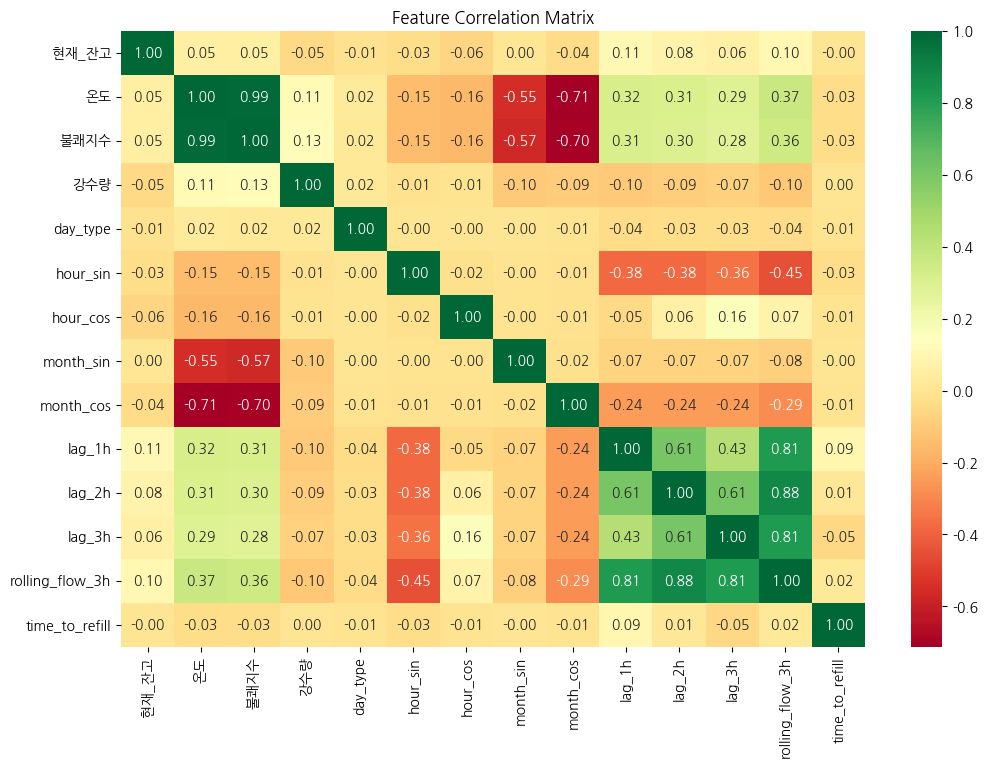

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석에 사용할 변수들만 추출
corr_df = df_1035_station[[target]+features ]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

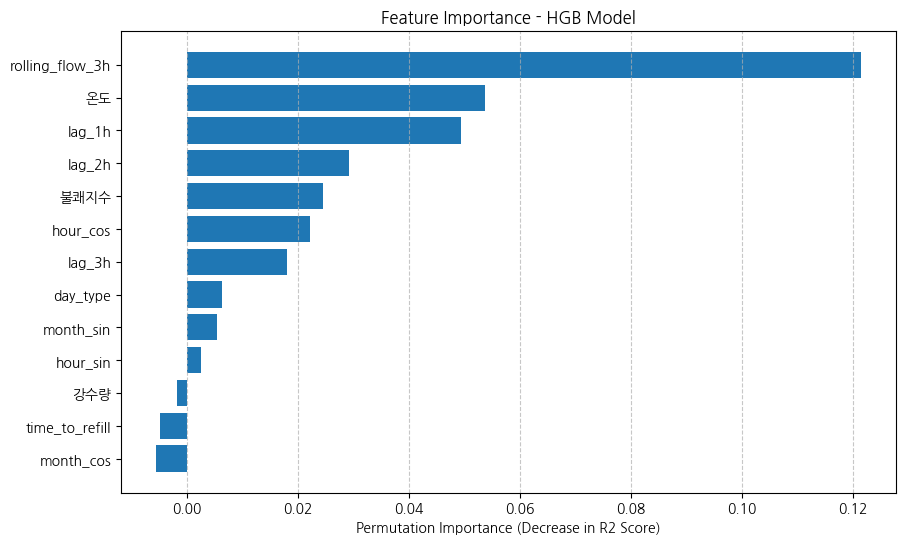

In [145]:
from sklearn.inspection import permutation_importance

# 테스트 데이터셋을 기준으로 측정합니다.
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

# 시각화를 위해 정렬
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - HGB Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

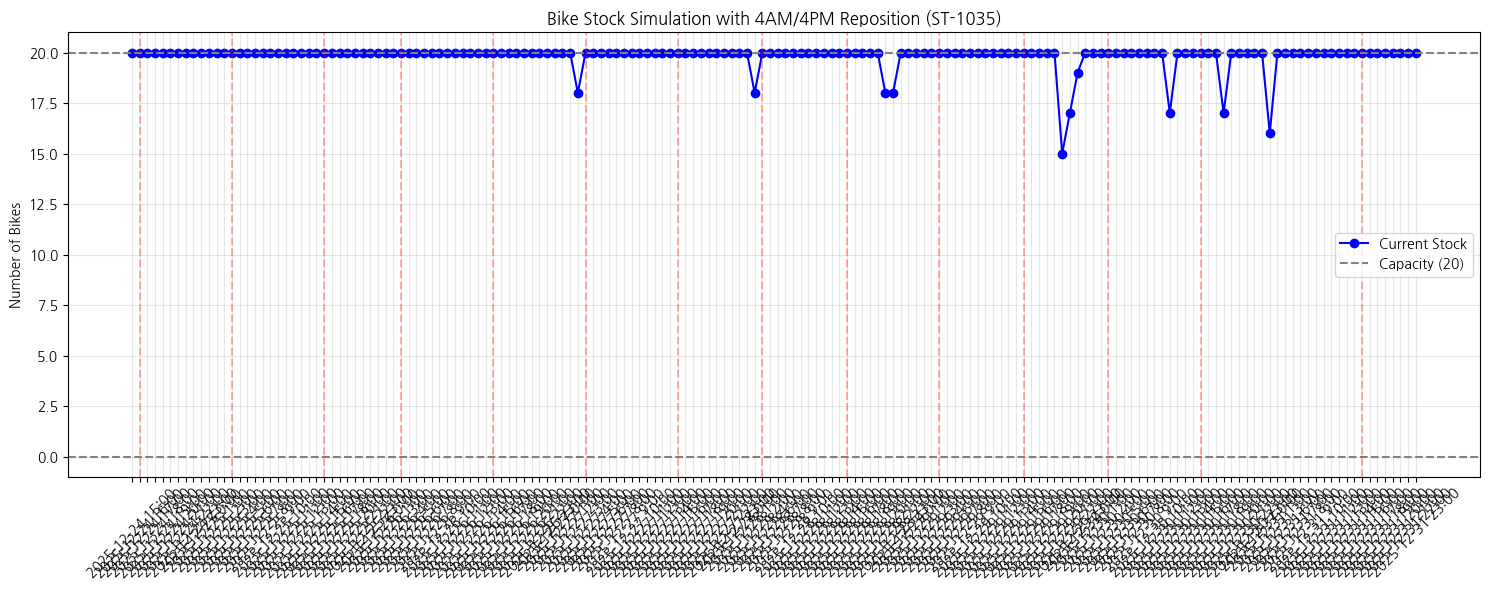

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화를 위해 최근 7일치 데이터만 추출
sample_df = df_1035_station.tail(24 * 7) 

plt.figure(figsize=(15, 6))
plt.plot(sample_df['기준_날짜'].astype(str) + " " + sample_df['시간대'].astype(str) + ":00", 
         sample_df['현재_잔고'], marker='o', linestyle='-', color='b', label='Current Stock')

# 재배치 시간(4시, 16시)에 수직선 표시
for i, row in sample_df.iterrows():
    if row['시간대'] in [4, 16]:
        plt.axvline(x=f"{row['기준_날짜'].date()} {row['시간대']}:00", color='r', linestyle='--', alpha=0.3)

plt.axhline(y=20, color='gray', linestyle='--', label='Capacity (20)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Bike Stock Simulation with 4AM/4PM Reposition (ST-1035)')
plt.xticks(rotation=45)
plt.ylabel('Number of Bikes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

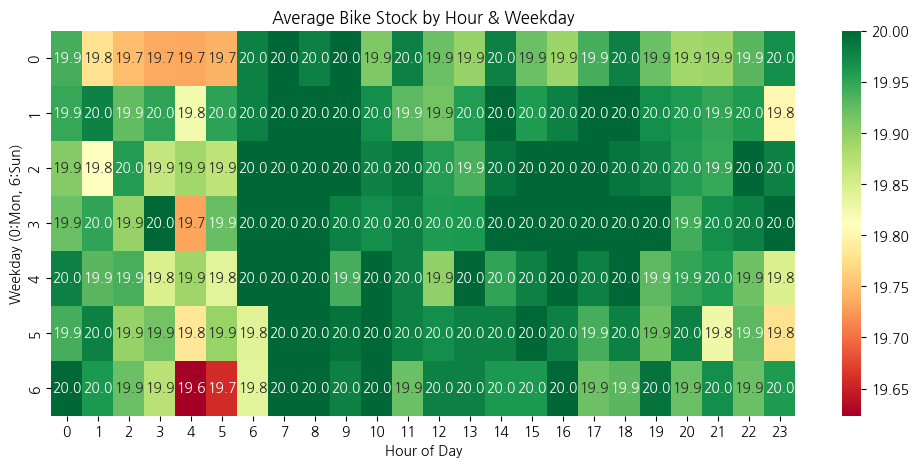

In [147]:
# 요일별, 시간별 평균 잔고 피벗 테이블
pivot_df = df_1035_station.pivot_table(values='현재_잔고', index='weekday', columns='시간대', aggfunc='mean')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_df, cmap='RdYlGn', annot=True, fmt=".1f")
plt.title('Average Bike Stock by Hour & Weekday')
plt.ylabel('Weekday (0:Mon, 6:Sun)')
plt.xlabel('Hour of Day')
plt.show()

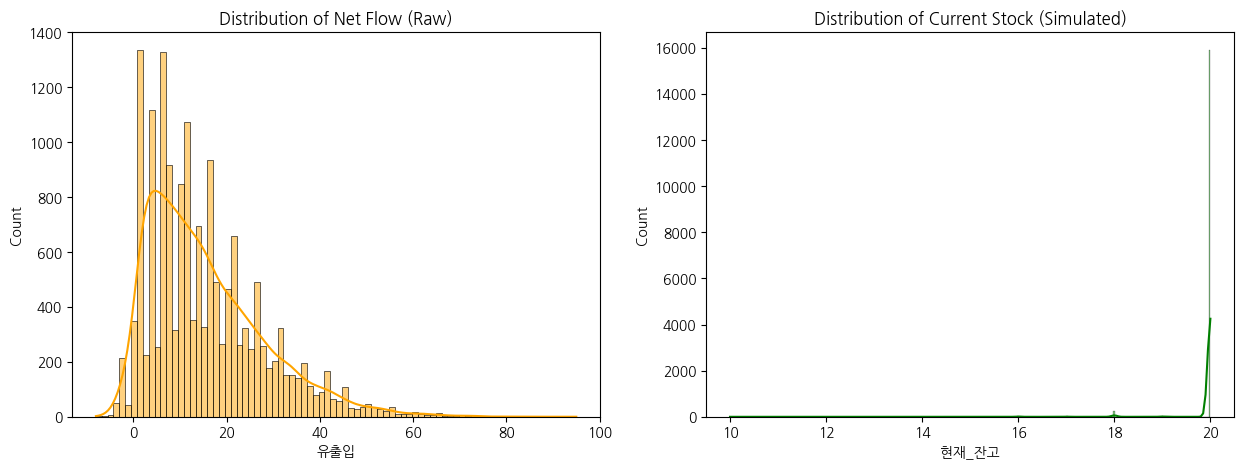

In [148]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_1035_station['유출입'], kde=True, color='orange')
plt.title('Distribution of Net Flow (Raw)')

plt.subplot(1, 2, 2)
sns.histplot(df_1035_station['현재_잔고'], kde=True, color='green')
plt.title('Distribution of Current Stock (Simulated)')
plt.show()